# Sentiment Analysis using TF-IDF and Logistic Regression

## Objective

The aim of this project is to classify customer reviews into positive or negative sentiments using Natural Language Processing (NLP).

The project demonstrates the complete NLP workflow, including text preprocessing, TF-IDF vectorization, model training using Logistic Regression, evaluation, and prediction on new customer reviews.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [3]:

df = pd.read_csv("IMDB_Dataset.csv")

df.head()

df.info()

df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


review       0
sentiment    0
dtype: int64

In [4]:

## Data Preprocessing

#Before training the model, the review text is cleaned by converting it to lowercase and removing punctuation and unnecessary characters.

def clean_text(text):

    text = text.lower()

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()


In [6]:

df["CleanReview"] = df["review"].apply(clean_text)

df.head()

X = df["CleanReview"]

y = df["sentiment"]

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(X)


In [7]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)


In [8]:

model = LogisticRegression()

model.fit(X_train,y_train)
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test,prediction)

print("Accuracy :",round(accuracy*100,2),"%")
print(classification_report(y_test,prediction))


Accuracy : 89.29 %
              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4961
    positive       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



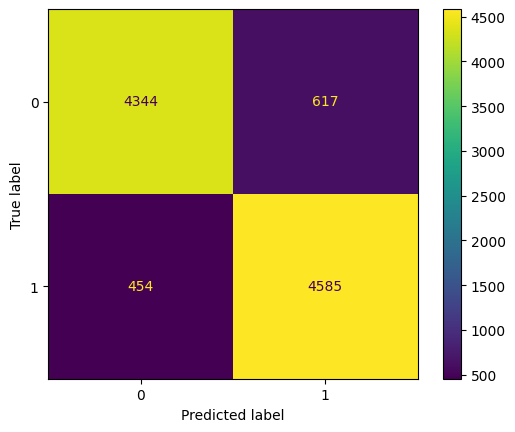

In [9]:

cm = confusion_matrix(y_test,prediction)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.show()


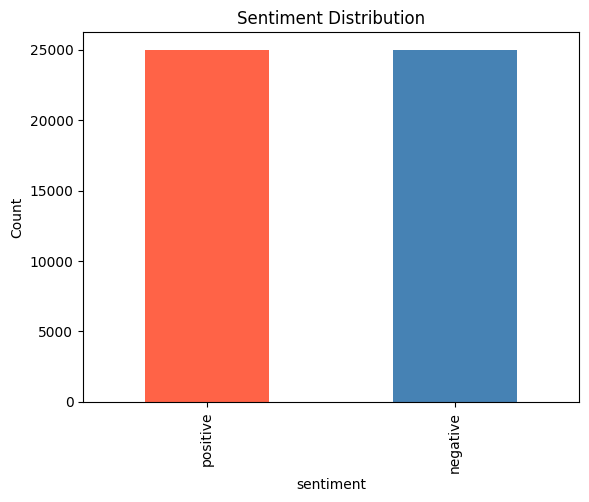

In [11]:

df["sentiment"].value_counts().plot(

    kind="bar",

    color=["tomato","steelblue"]

)

plt.title("Sentiment Distribution")

plt.xlabel("sentiment")

plt.ylabel("Count")

plt.show()


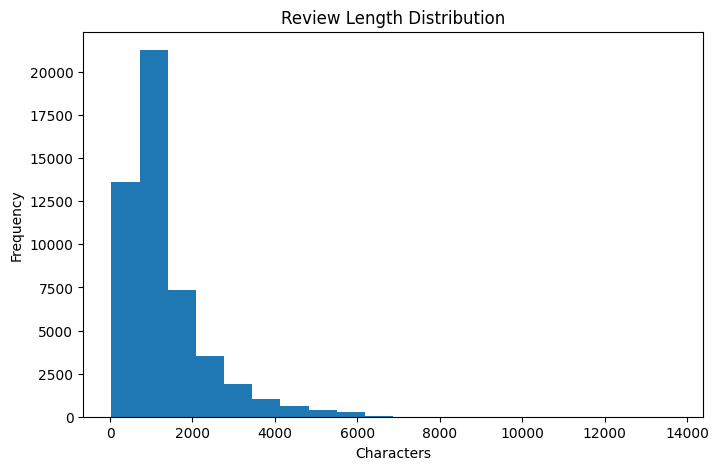

In [13]:

review_length = df["review"].str.len()

plt.figure(figsize=(8,5))

plt.hist(review_length,bins=20)

plt.title("Review Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()


In [14]:

sample = [

    "The product quality is amazing and I loved it."

]

sample = [clean_text(i) for i in sample]

sample = vectorizer.transform(sample)

print(

model.predict(sample)[0]

)
sample = [

    "Very poor quality and completely disappointed."

]

sample = [clean_text(i) for i in sample]

sample = vectorizer.transform(sample)

print(

model.predict(sample)[0]

)


positive
negative


# Conclusion

In this project, customer reviews were classified into positive and negative sentiments using Natural Language Processing techniques.

The text data was preprocessed and transformed into numerical features using TF-IDF vectorization. A Logistic Regression classifier was trained to predict customer sentiment effectively.

The obtained results demonstrate that traditional machine learning algorithms com